# scPhyTr round trip: simulate a full model, then recover every feature

scPhyTr's modular pieces run both ways. Here we **simulate** a panel of genes from a tree × a
multivariate Brownian-motion trait model × a subclonal negative-binomial observation, planting
a known structure:

* a **co-evolving module** of genes (high rate, correlated),
* independent **heritable** genes (high rate, little within-clone noise),
* **plastic** genes (low rate, high within-clone variance),

then **infer** each property back through the scanpy-like API and check we recover the truth:
per-gene **rate**, **heritability** (λ), **plasticity**, and the **gene–gene correlation** matrix.

## 0. Setup

In [1]:
import os, sys
root = os.getcwd()
while root != "/" and not os.path.isdir(os.path.join(root, "src", "scphytr")):
    root = os.path.dirname(root)
sys.path[:0] = [root, os.path.join(root, "src")]; os.chdir(root)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scphytr as ph
from ete3 import Tree as ETree

et = ETree(); et.populate(60, random_branches=True)
for nd in et.traverse():
    if not nd.is_root(): nd.dist = round(max(float(nd.dist), 0.1), 3)
for i, l in enumerate(et.get_leaves()): l.name = f"c{i}"
tree = ph.Tree(); tree.phylotree = et; tree.root = et.get_tree_root()
print(f"{len(et.get_leaves())} leaves")

60 leaves


## 1. Plant the ground truth — a 12-gene panel

The diagonal of the diffusion matrix $K$ is each gene's **rate** (heritability); its off-diagonal
is **co-evolution**. A per-gene negative-binomial dispersion $r$ controls **within-clone
plasticity** (small $r$ = plastic).

In [2]:
GROUPS = ["module"]*4 + ["heritable"]*4 + ["plastic"]*4
names  = [f"mod{i}" for i in range(4)] + [f"her{i}" for i in range(4)] + [f"pla{i}" for i in range(4)]
rates  = np.array([2,2,2,2,  1,1,1,1,  0.3,0.3,0.3,0.3], float)   # K diagonal
disp   = np.array([50]*8 + [1.5]*4, float)                        # small r = plastic
K = np.diag(rates); rho = 0.85
for i in range(4):                                               # correlate the module block
    for j in range(4):
        if i != j: K[i, j] = rho*np.sqrt(rates[i]*rates[j])

adata = ph.simulate_panel(tree, K, dispersion=disp, n_cells=6, mean_size=400,
                          gene_names=names, seed=1)
ph.pp.setup_anndata(adata, tree)
adata.var["group"] = GROUPS
print(adata)

AnnData object with n_obs × n_vars = 360 × 12
    obs: 'species', 'size_factors', '_leaf_index'
    var: 'true_rate', 'true_dispersion', 'group'
    uns: 'true_K', 'true_K_corr', 'true_latent', 'tree', '_species_obs', '_size_factor_obs'


### The simulated data

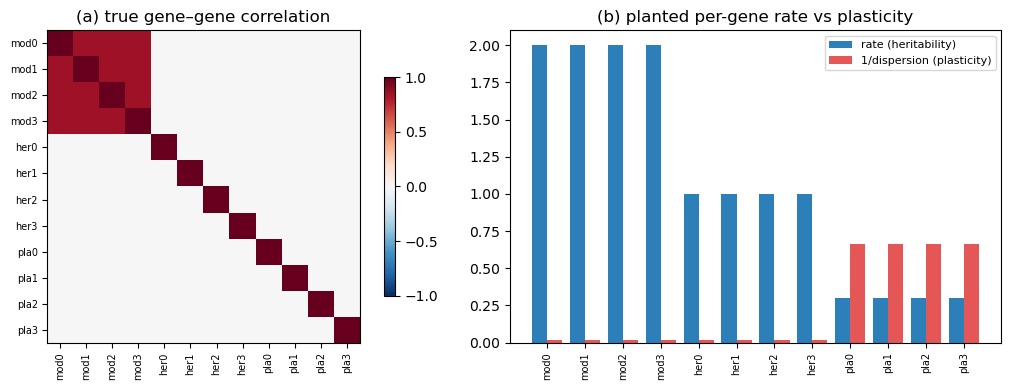

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# (a) the TRUE gene-gene correlation: a co-evolving module block
im = ax[0].imshow(adata.uns["true_K_corr"], cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set_xticks(range(12)); ax[0].set_xticklabels(names, rotation=90, fontsize=7)
ax[0].set_yticks(range(12)); ax[0].set_yticklabels(names, fontsize=7)
ax[0].set_title("(a) true gene–gene correlation"); fig.colorbar(im, ax=ax[0], shrink=0.7)
# (b) the planted per-gene rate and plasticity
x = np.arange(12); w = 0.4
ax[1].bar(x - w/2, adata.var["true_rate"], w, color="#2c7fb8", label="rate (heritability)")
ax[1].bar(x + w/2, 1/np.array(disp), w, color="#e45756", label="1/dispersion (plasticity)")
ax[1].set_xticks(x); ax[1].set_xticklabels(names, rotation=90, fontsize=7)
ax[1].set_title("(b) planted per-gene rate vs plasticity"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

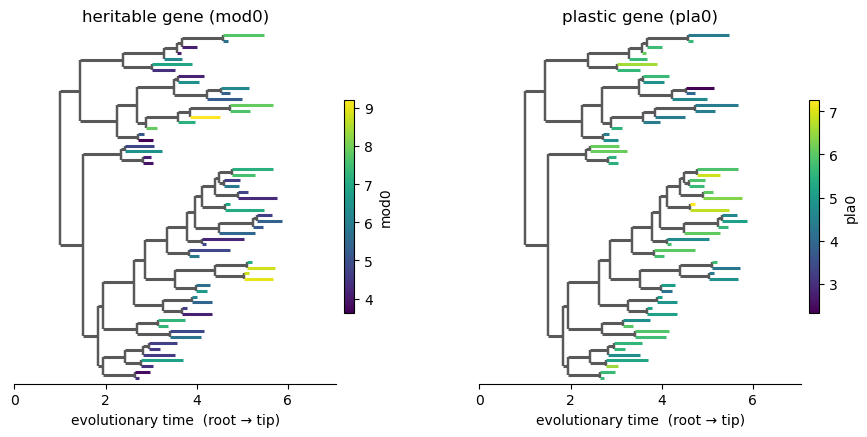

In [4]:
# (c) a heritable gene vs a plastic gene, on the tree (heritable = structured, plastic = noisy)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
ph.pl.plot_tree(adata, color="mod0", ax=ax[0], label_leaves=False); ax[0].set_title("heritable gene (mod0)")
ph.pl.plot_tree(adata, color="pla0", ax=ax[1], label_leaves=False); ax[1].set_title("plastic gene (pla0)")
plt.show()

## 2. Recover every feature through the API

In [5]:
ph.tl.estimate_rate(adata)                                   # per-gene rate σ²
ph.tl.heritability(adata)                                    # Pagel's λ
ph.tl.plasticity(adata, genes=list(adata.var_names))         # within-clone plasticity index
ph.tl.evolutionary_correlation(adata, genes=list(adata.var_names))   # gene-gene K
ph.tl.factor_analysis(adata, k=2, genes=list(adata.var_names))       # modules
print(adata.var[["group", "true_rate", "rate", "lambda", "plasticity"]].round(2).to_string())

          group  true_rate  rate  lambda  plasticity
mod0     module        2.0  1.46    1.00        0.00
mod1     module        2.0  2.01    1.00        0.00
mod2     module        2.0  1.57    0.97        0.00
mod3     module        2.0  1.50    1.00        0.00
her0  heritable        1.0  1.16    0.93        0.00
her1  heritable        1.0  1.16    0.98        0.00
her2  heritable        1.0  1.14    0.81        0.00
her3  heritable        1.0  1.03    1.00        0.00
pla0    plastic        0.3  0.51    0.71        0.27
pla1    plastic        0.3  0.55    0.73        0.39
pla2    plastic        0.3  0.63    0.67        0.33
pla3    plastic        0.3  0.69    0.79        0.22


### Recovery — does it match the truth?

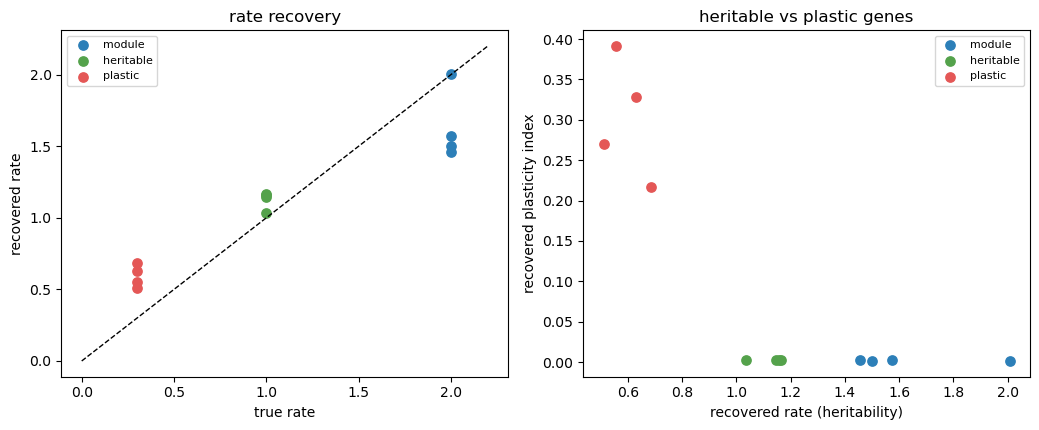

In [6]:
col = {"module": "#2c7fb8", "heritable": "#54a24b", "plastic": "#e45756"}
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.4))
# rate: recovered vs true (on the diagonal)
for grp in col:
    m = adata.var["group"] == grp
    ax[0].scatter(adata.var.loc[m, "true_rate"], adata.var.loc[m, "rate"],
                  color=col[grp], s=45, label=grp)
ax[0].plot([0, 2.2], [0, 2.2], "k--", lw=1)
ax[0].set_xlabel("true rate"); ax[0].set_ylabel("recovered rate"); ax[0].set_title("rate recovery")
ax[0].legend(fontsize=8)
# heritable vs plastic: recovered plasticity vs recovered rate separates the groups
for grp in col:
    m = adata.var["group"] == grp
    ax[1].scatter(adata.var.loc[m, "rate"], adata.var.loc[m, "plasticity"],
                  color=col[grp], s=45, label=grp)
ax[1].set_xlabel("recovered rate (heritability)"); ax[1].set_ylabel("recovered plasticity index")
ax[1].set_title("heritable vs plastic genes"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

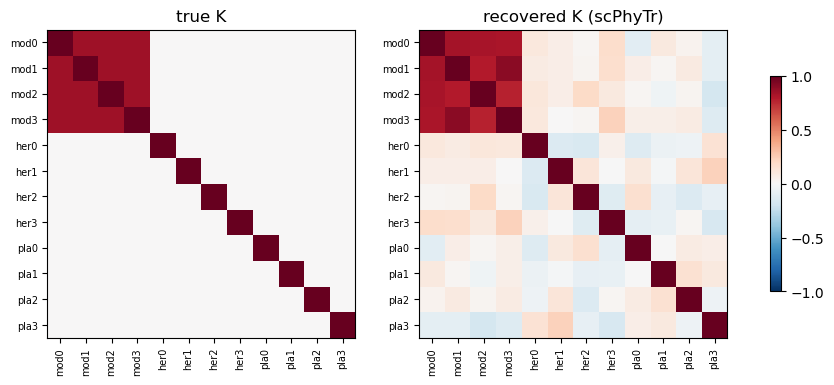

module block mean |corr|: true 0.85  recovered 0.82


In [7]:
# gene-gene co-evolution: true vs recovered K
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (M, t) in zip(ax, [(adata.uns["true_K_corr"], "true K"),
                          (adata.uns["K_corr"], "recovered K (scPhyTr)")]):
    im = a.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    a.set_xticks(range(12)); a.set_xticklabels(names, rotation=90, fontsize=7)
    a.set_yticks(range(12)); a.set_yticklabels(names, fontsize=7); a.set_title(t)
fig.colorbar(im, ax=ax, shrink=0.7); plt.show()

mod = np.arange(4); iu = np.triu_indices(4, 1)
print(f"module block mean |corr|: true {np.abs(adata.uns['true_K_corr'][np.ix_(mod,mod)][iu]).mean():.2f}"
      f"  recovered {np.abs(adata.uns['K_corr'][np.ix_(mod,mod)][iu]).mean():.2f}")

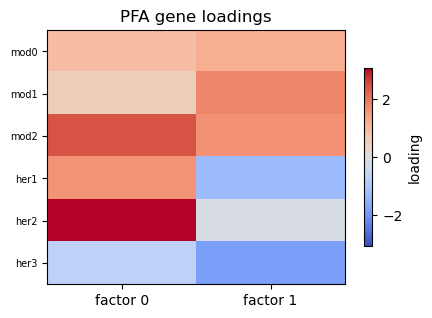

In [8]:
# modules: the co-evolving block emerges as a factor
ph.pl.loadings(adata, top=4); plt.show()

## Wrap-up

From one simulated panel, scPhyTr recovered, through the public API, every planted feature:
the per-gene **rate** (on the diagonal), the **heritable-vs-plastic** split (`tl.heritability` /
`tl.plasticity`), and the **co-evolving module** (`tl.evolutionary_correlation` / `tl.factor_analysis`).
The same modular components ran forwards (`ph.simulate_panel`: tree × trait model × observation)
and backwards (`ph.tl.*`). See [`analysis/benchmark/simulation_study.py`](../analysis/benchmark/simulation_study.py)
for the depth-sweep study (the count model is what keeps recovery honest at low depth).